In [182]:
import sys
import time
import torch
import numpy as np
import torch.nn as nn
from tqdm import trange
from pathlib import Path
import torch.optim as optim
import scipy.constants as sc
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from torch.utils.data import DataLoader, TensorDataset
# # import  settings

sys.path.append('..')
import plot_settings
plot_settings.apply()

import importlib
import sim_PyBaMM
importlib.reload(sim_PyBaMM)

import exp_pybamm
importlib.reload(exp_pybamm);

In [240]:
# Parameters
sol, model, params = sim_PyBaMM.simulate_DC1(I0=0.5, T=1000, T_horizon=3600)
t = np.linspace(0,sol['Time [s]'].entries[-1],1000)
Dn = sol.observe(model.variables['X-averaged negative particle effective diffusivity [m2.s-1]'])(t)[-1,0]
c0 = sol.observe(model.variables['X-averaged negative particle concentration [mol.m-3]'])(t)[:, 0]
Ln = params['Negative electrode thickness [m]']
# Lp = params['Positive electrode thickness [m]']
A = params['Electrode height [m]'] * params['Electrode width [m]']
R = params['Negative particle radius [m]']
en = params['Negative electrode active material volume fraction']
# ep = params['Positive electrode active material volume fraction']
# ap = 3 * ep / R
an = 3 * en / R

F = sc.physical_constants['Faraday constant'][0]
I = 0.5

def Neumann_bcR(Dn=Dn, F=F, an=an, A=A, Ln=Ln):
    return (Dn*F*an*A*Ln)

In [241]:
class Net(nn.Module):
    def __init__(self, input_size=2, hidden_size=128):
        super(Net, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(input_size, hidden_size),
            nn.ReLU(),
            nn.Linear(hidden_size, hidden_size),
            nn.ReLU(),
            nn.Linear(hidden_size, 1)
        )
    
    def forward(self, x):
        x = self.net(x)
        return x
    
model = Net()
optimizer = optim.Adam(model.parameters(), lr=1e-3)


def grad(outputs, inputs):
    return torch.autograd.grad(
        outputs, inputs, grad_outputs=torch.ones_like(outputs), create_graph=True
    )[0]

def ic_loss(model):
    # Initial condition u(r, 0) = c0
    c0 = 1.0
    r_ic = torch.linspace(0, 1, 100).reshape(-1, 1)
    t_ic = torch.zeros(100, 1)
    
    tr_ic = torch.cat([t_ic, r_ic], dim=1)
    u_ic = model(tr_ic)
    return torch.mean((u_ic - c0)**2)

def bc_loss(model, I):
    # Boundary condition du/dr|_{r=0} = 0
    t_bc = torch.linspace(0, 1, 100).reshape(-1, 1)  # (100, 1)

    r0 = torch.zeros(100, 1).requires_grad_(True)  # r=0 boundary
    u_r0 = model(torch.cat([t_bc, r0], dim=1))
    du_dr0 = grad(u_r0, r0)
    bc_0 = torch.mean(du_dr0**2)

    # Boundary condition du/dr_{r=R} = I/(Dn*F*an*Ln)
    rR = torch.ones(100, 1).requires_grad_(True)  # r=R boundary
    u_rR = model(torch.cat([t_bc, rR], dim=1))
    du_drR = grad(u_rR, rR)
    bc_R = torch.mean((du_drR - I / Neumann_bcR())**2)
    return bc_0 + bc_R

def physics_loss(y_pred, T, R, Dn):
    # compute du/dt du/dr
    du_dt = grad(y_pred, T)
    du_dr = grad(y_pred, R)
    d2u_dr2 = grad(du_dr, R)

    # PDE du/dt - D / r^2 * d/dr[r^2 * du/dr] = 0 # Expanded: du/dt - D  * (2 / r * du/dr + d^2u/dr^2) = 0
    pde = du_dt - Dn * (2 / (R + 1e-8) * du_dr + d2u_dr2)
    return torch.mean(pde**2)

In [242]:
# Collocation points — meshgrid of t and r
t_1d = torch.linspace(0, 1, 100)
r_1d = torch.linspace(0, 1, 100)
T, R = torch.meshgrid(t_1d, r_1d, indexing='ij')  # each (100, 100)
T = T.reshape(-1, 1).requires_grad_(True)          # (10000, 1)
R = R.reshape(-1, 1).requires_grad_(True)          # (10000, 1)
TR = torch.cat([T, R], dim=1)                      # (10000, 2)

In [243]:
def training(epochs=50, tol=2.5e-4, model=model, optimizer=optimizer):
    history = {'loss': []}
    model.train()
    
    for epoch in range(epochs):
        y_pred = model(TR)

        p_loss = physics_loss(y_pred, T, R, Dn)
        i_loss = ic_loss(model)
        b_loss = bc_loss(model, I=0.5)

        loss = p_loss + i_loss + b_loss

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        history['loss'].append(p_loss.item())

        if epoch % 100 == 0:
            print(f'Epoch {epoch+1} loss: {p_loss:.5f}')

    return model, history

In [244]:
model, history = training(epochs=500, model=model, optimizer=optimizer)

Epoch 1 loss: 0.00149
Epoch 101 loss: 0.25327
Epoch 201 loss: 1.13351
Epoch 301 loss: 0.88010
Epoch 401 loss: 0.28923


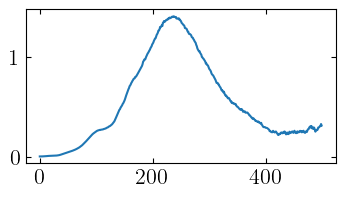

In [245]:
plt.figure(figsize=(4,2))
plt.plot(history['loss'])

(100, 100)


Text(0, 0.5, 'u(t, r=0.81)')

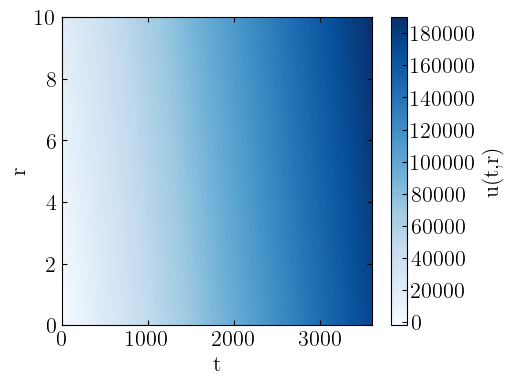

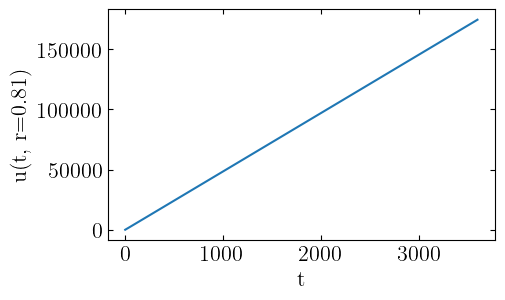

In [246]:
t_horizon = 3600
r_horizon = 10.0
t_num = 100
r_num = 100
t_1d = torch.linspace(0, t_horizon, t_num)
r_1d = torch.linspace(0, r_horizon, r_num)
T_mesh, R_mesh = torch.meshgrid(t_1d, r_1d, indexing='ij')  # each (1000, 1000)
T = T_mesh.reshape(-1, 1).requires_grad_(True)          # (1000000, 1)
R = R_mesh.reshape(-1, 1).requires_grad_(True)          # (1000000, 1)
TR_test = torch.cat([T, R], dim=1)                      # (1000000, 2)

pred = model(TR_test).detach().numpy().reshape(t_num, r_num) # Shape (1000, 1000) = (t_index, r_index)
print(pred.shape)

plt.figure(figsize=(5,4))
plt.contourf(T_mesh.detach().numpy(), R_mesh.detach().numpy(), pred, levels=100, cmap='Blues')
plt.xlabel('t')
plt.ylabel('r')
plt.colorbar(label='u(t,r)')

# Fixed r plot u(t)
r_target = 0.8
r_idx = torch.argmin(torch.abs(r_1d - r_target)).item()

plt.figure(figsize=(5, 3))
plt.plot(t_1d.numpy(), pred[:, r_idx])
plt.xlabel('t')
plt.ylabel(f'u(t, r={r_1d[r_idx]:.2f})')